# §3 · Capital Asset Pricing Model (CAPM)
**Bachelorarbeit: Kritik des CAPM und Erweiterung durch das Black-Litterman-Modell**  
Lucas Posern · TU Dresden · 2026

> LaTeX: `CAPM.tex`

Analysen: Zeitreihenregressionen (OLS), Querschnittsregression, SML, Jensen's Alpha,  
MV-Sensitivitätsanalyse (Michaud-Effekt), Backtest CAPM-Baseline vs. naives MV.  
Läuft vollständig offline, ohne Internetzugang.

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# core/ auf sys.path
ROOT = Path(os.path.abspath(''))   # = Thesis_code_abgabe/
CORE = ROOT / 'core'
DATA = ROOT / 'data'
if str(CORE) not in sys.path:
    sys.path.insert(0, str(CORE))

# Thesis-Module

# Plot-Stil
plt.rcParams.update({
    'figure.dpi': 130, 'figure.figsize': (9, 4.5),
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'lines.linewidth': 1.8,
})
C = ['#1f4e79', '#c00000', '#538135', '#7030a0', '#833c00', '#005073']
from IPython.display import display
print('Setup abgeschlossen.')

import statsmodels.api as sm
from portfolio_metrics import performance_summary, cumulative_returns as cum_ret

Setup abgeschlossen.


---
## §3.2 · Daten laden (Idzorek-Universum, offline)

In [2]:
# Idzorek-Multi-Asset-Universum aus lokalem CSV-Cache (kein Fama-French)
TICKERS = ["AGG", "BWX", "IWF", "IWD", "IWO", "IWN", "EFA", "EEM"]
ETF_META = {
    "AGG": {"label": "US Bonds\n(AGG)",      "w_eq": 0.1934},
    "BWX": {"label": "Intl Bonds\n(BWX)",    "w_eq": 0.2613},
    "IWF": {"label": "US Lg Growth\n(IWF)",  "w_eq": 0.1209},
    "IWD": {"label": "US Lg Value\n(IWD)",   "w_eq": 0.1209},
    "IWO": {"label": "US Sm Growth\n(IWO)",  "w_eq": 0.0134},
    "IWN": {"label": "US Sm Value\n(IWN)",   "w_eq": 0.0134},
    "EFA": {"label": "Intl Dev\n(EFA)",      "w_eq": 0.2418},
    "EEM": {"label": "Emg Mkts\n(EEM)",      "w_eq": 0.0349},
}
total = sum(v["w_eq"] for v in ETF_META.values())
for t in ETF_META:
    ETF_META[t]["w_eq"] /= total
# Gleichgewichtsgewichte: globales Marktportfolio (Idzorek et al.), Trainingsstart 2008
_eq_file = DATA / "eq_weights_train_start.csv"
if _eq_file.exists():
    _eq_df    = pd.read_csv(_eq_file, index_col=0)
    _eq_total = _eq_df["w_eq"].sum()
    for t in ETF_META:
        ETF_META[t]["w_eq"] = float(_eq_df.at[t, "w_eq"]) / _eq_total
    print("w_eq: Idzorek-Marktportfolio-Gewichte (2008) geladen.")
else:
    print("w_eq: Idzorek-Fallback (eq_weights_train_start.csv nicht gefunden)")
# ETF-Renditen (^IRX rf, ^GSPC Markt -- identisch mit 04_BLM.ipynb)
_ret = pd.read_csv(DATA / "etf_returns_monthly.csv", index_col=0, parse_dates=True)
_ret.index = pd.to_datetime(_ret.index).to_period("M").to_timestamp("M")
_rf = pd.read_csv(DATA / "rf_monthly.csv", index_col=0, parse_dates=True)
rf_series = _rf.iloc[:, 0] if isinstance(_rf, pd.DataFrame) else _rf
rf_series.index = pd.to_datetime(rf_series.index).to_period("M").to_timestamp("M")
_mkt = pd.read_csv(DATA / "spx_returns_monthly.csv", index_col=0, parse_dates=True)
mkt_series = _mkt.iloc[:, 0] if isinstance(_mkt, pd.DataFrame) else _mkt
mkt_series.index = pd.to_datetime(mkt_series.index).to_period("M").to_timestamp("M")
df           = _ret[TICKERS].copy()
df["RF"]     = rf_series.reindex(df.index)
df["Mkt-RF"] = mkt_series.reindex(df.index)
df           = df.dropna()
TICKERS = [t for t in df.columns if t in TICKERS]
print(f"Daten: {df.index.min().date()} - {df.index.max().date()}  ({len(df)} Monate)")
print(f"Quellen: ETF-Renditen (yfinance), RF (^IRX), Mkt-RF (^GSPC - RF)")


w_eq: Idzorek-Marktportfolio-Gewichte (2008) geladen.
Daten: 2008-01-31 - 2024-12-31  (204 Monate)
Quellen: ETF-Renditen (yfinance), RF (^IRX), Mkt-RF (^GSPC - RF)


---
## §3.2 · CAPM-Zeitreihenregressionen (OLS)

In [4]:
rows = []
for t in TICKERS:
    y   = df[t] - df["RF"]
    X   = sm.add_constant(df["Mkt-RF"])
    res = sm.OLS(y, X).fit()
    rows.append({
        "ticker":          t,
        "label":           ETF_META[t]["label"],
        "alpha":           res.params["const"],
        "alpha_pct":       res.params["const"] * 100.0,
        "beta":            res.params["Mkt-RF"],
        "t_alpha":         res.tvalues["const"],
        "p_alpha":         res.pvalues["const"],
        "r2":              res.rsquared,
        "mean_excess_pct": (df[t] - df["RF"]).mean() * 100.0,
    })

out = pd.DataFrame(rows).set_index("ticker")
print(out[["alpha_pct", "beta", "t_alpha", "p_alpha", "r2"]].round(4))

        alpha_pct    beta  t_alpha  p_alpha      r2
ticker                                             
AGG        0.0813  0.0758   0.8352   0.4046  0.0608
BWX       -0.2452  0.2679  -1.4687   0.1435  0.2156
IWF        0.3391  1.0343   3.5712   0.0004  0.9268
IWD       -0.0672  0.9979  -0.6618   0.5089  0.9115
IWO       -0.0572  1.1964  -0.2775   0.7817  0.7826
IWN       -0.1268  1.1673  -0.5662   0.5719  0.7438
EFA       -0.4203  1.0131  -2.3095   0.0219  0.7679
EEM       -0.5327  1.0279  -1.9065   0.0580  0.5909


---
## §3.2 · Querschnittsregression (SML-Test)

Querschnittsregression: gamma0=-0.0663, gamma1=0.6198, R2=0.481, p=0.056


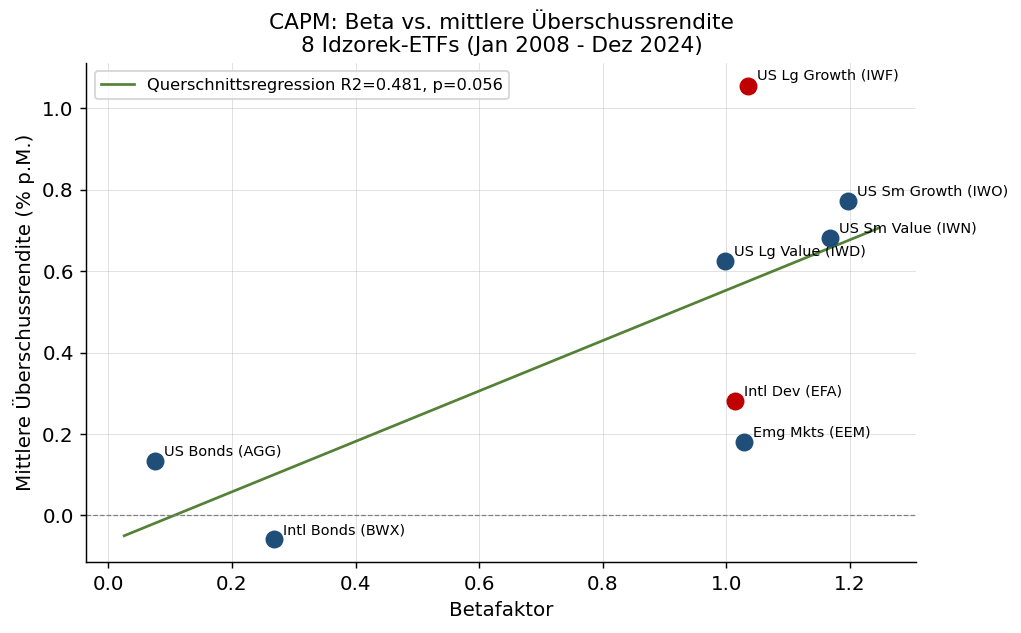

In [5]:
X_cs = sm.add_constant(out["beta"])
y_cs = out["mean_excess_pct"]
cs   = sm.OLS(y_cs, X_cs).fit()
print(f"Querschnittsregression: gamma0={cs.params['const']:.4f}, "
      f"gamma1={cs.params['beta']:.4f}, R2={cs.rsquared:.3f}, p={cs.pvalues['beta']:.3f}")

# Plot 1: Beta vs. mittlere Überschussrendite
fig, ax = plt.subplots(figsize=(8, 5))
for t in TICKERS:
    col = C[1] if out.loc[t, "p_alpha"] <= 0.05 else C[0]
    ax.scatter(out.loc[t, "beta"], out.loc[t, "mean_excess_pct"], color=col, s=80, zorder=5)
    ax.annotate(ETF_META[t]["label"].replace("\n", " "),
                xy=(out.loc[t, "beta"], out.loc[t, "mean_excess_pct"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)

x_line = np.linspace(out["beta"].min() - 0.05, out["beta"].max() + 0.05, 200)
y_line = cs.params["const"] + cs.params["beta"] * x_line
ax.plot(x_line, y_line, color=C[2], linewidth=1.5,
        label=f"Querschnittsregression R2={cs.rsquared:.3f}, p={cs.pvalues['beta']:.3f}")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_xlabel("Betafaktor", fontsize=11)
ax.set_ylabel("Mittlere Überschussrendite (% p.M.)", fontsize=11)
ax.set_title("CAPM: Beta vs. mittlere Überschussrendite\n8 Idzorek-ETFs (Jan 2008 - Dez 2024)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
display(fig)
plt.close(fig)

---
## §3.2 · Jensen's Alpha

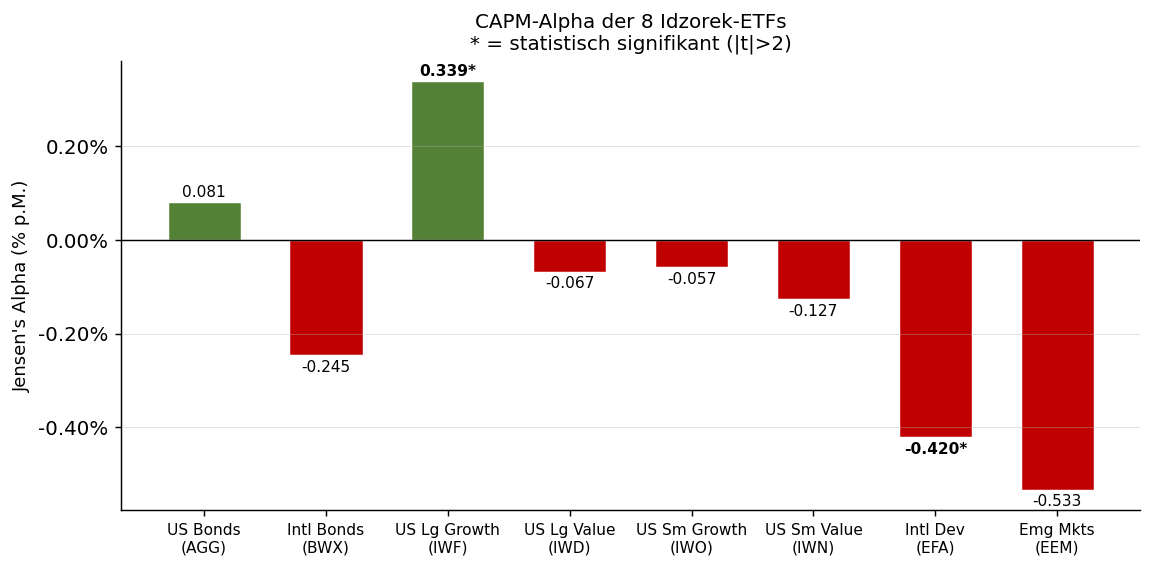

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x      = np.arange(len(TICKERS))
alphas = out.loc[TICKERS, "alpha_pct"].values
t_vals = out.loc[TICKERS, "t_alpha"].values
sig    = np.abs(t_vals) > 2.0
colors = [C[1] if a < 0 else C[2] for a in alphas]
bars   = ax.bar(x, alphas, color=colors, edgecolor="white", linewidth=0.8, width=0.6)

for i, (b, s) in enumerate(zip(bars, sig)):
    ht    = b.get_height()
    label = f"{alphas[i]:.3f}" + ("*" if s else "")
    ypos  = ht + 0.005 if ht >= 0 else ht - 0.01
    ax.text(b.get_x() + b.get_width() / 2, ypos, label,
            ha="center", va="bottom" if ht >= 0 else "top",
            fontsize=8.5, fontweight="bold" if s else "normal")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([ETF_META[t]["label"] for t in TICKERS], fontsize=8.5)
ax.set_ylabel("Jensen's Alpha (% p.M.)", fontsize=10)
ax.set_title("CAPM-Alpha der 8 Idzorek-ETFs\n* = statistisch signifikant (|t|>2)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)
plt.tight_layout()
display(fig)
plt.close(fig)

---
## §3.2 · MV-Sensitivitätsanalyse (Michaud-Effekt)

Konditionszahl Sigma (ETF, Trainingsperiode 2008-2018): 341.8
Mittlere monatliche Excess-Rendite der ETFs (%):
  AGG: +0.263%
  BWX: +0.131%
  IWF: +0.764%
  IWD: +0.509%
  IWO: +0.736%
  IWN: +0.613%
  EFA: +0.156%
  EEM: +0.161%

Tangentialportfolio-Gewichte (unrestringiert, Trainingsperiode):
  AGG: +82.0%
  BWX: +3.5%
  IWF: +69.4%
  IWD: -13.6%
  IWO: -14.8%
  IWN: +13.0%
  EFA: -30.7%
  EEM: -8.9%

Sensitivität L1-Änderung bei +0.1% Perturbation:
  Maximum: 74.0 pp (IWF)
  Median:  62.2 pp


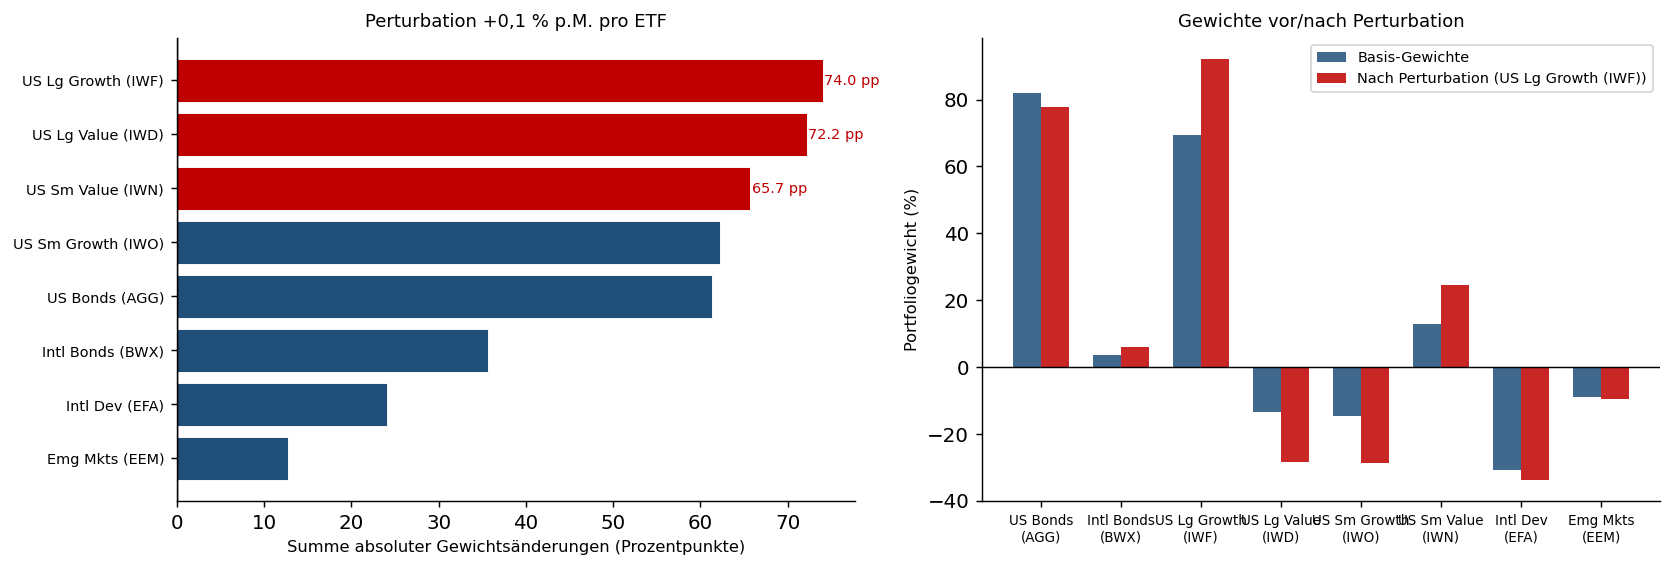

In [7]:
n       = len(TICKERS)
# Sensitivitätsanalyse auf Trainingsdaten (Jan 2008 - Dez 2018), konsistent mit Backtest
train_mask_mv = (df.index >= "2008-01-01") & (df.index <= "2018-12-31")
exc_ret = df.loc[train_mask_mv, TICKERS].subtract(df.loc[train_mask_mv, "RF"], axis=0)
mu      = exc_ret.mean().values
Sigma   = exc_ret.cov().values
print(f"Konditionszahl Sigma (ETF, Trainingsperiode 2008-2018): {np.linalg.cond(Sigma):.1f}")
print(f"Mittlere monatliche Excess-Rendite der ETFs (%):")
for t, m in zip(TICKERS, mu * 100):
    print(f"  {t}: {m:+.3f}%")

def tangency_weights(mu_vec, Sigma_mat):
    try:
        w_raw = np.linalg.solve(Sigma_mat, mu_vec)
    except np.linalg.LinAlgError:
        w_raw = np.linalg.lstsq(Sigma_mat, mu_vec, rcond=None)[0]
    return w_raw / w_raw.sum()

w_base     = tangency_weights(mu, Sigma)
delta_pert = 0.001
l1_changes = []
for k in range(n):
    mu_p = mu.copy()
    mu_p[k] += delta_pert
    l1_changes.append(float(np.sum(np.abs(tangency_weights(mu_p, Sigma) - w_base))) * 100.0)

print(f"\nTangentialportfolio-Gewichte (unrestringiert, Trainingsperiode):")
for t, w in zip(TICKERS, w_base * 100):
    print(f"  {t}: {w:+.1f}%")
print(f"\nSensitivität L1-Änderung bei +0.1% Perturbation:")
print(f"  Maximum: {max(l1_changes):.1f} pp ({TICKERS[l1_changes.index(max(l1_changes))]})")
print(f"  Median:  {sorted(l1_changes)[len(l1_changes)//2]:.1f} pp")

order        = np.argsort(l1_changes)[::-1]
sorted_names = [ETF_META[TICKERS[i]]["label"].replace("\n", " ") for i in order]
sorted_l1    = [l1_changes[i] for i in order]
bar_cols     = [C[1] if i < 3 else C[0] for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.barh(range(n), sorted_l1[::-1], color=bar_cols[::-1], edgecolor="white", linewidth=0.5)
ax.set_yticks(range(n))
ax.set_yticklabels(sorted_names[::-1], fontsize=8)
ax.set_xlabel("Summe absoluter Gewichtsänderungen (Prozentpunkte)", fontsize=9)
ax.set_title("Perturbation +0,1 % p.M. pro ETF", fontsize=10)
ax.axvline(0, color="black", linewidth=0.8)
for i in range(min(3, n)):
    ax.text(sorted_l1[i] + 0.2, n - 1 - i, f"{sorted_l1[i]:.1f} pp",
            va="center", fontsize=8, color=C[1])

k_max  = order[0]
mu_p   = mu.copy()
mu_p[k_max] += delta_pert
w_pert = tangency_weights(mu_p, Sigma)
ax2    = axes[1]
x_r    = np.arange(n)
w_     = 0.35
ax2.bar(x_r - w_/2, w_base * 100, w_, label="Basis-Gewichte", color=C[0], alpha=0.85)
ax2.bar(x_r + w_/2, w_pert * 100, w_,
        label=f"Nach Perturbation ({ETF_META[TICKERS[k_max]]['label'].replace(chr(10), ' ')})",
        color=C[1], alpha=0.85)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x_r)
ax2.set_xticklabels([ETF_META[t]["label"] for t in TICKERS], fontsize=7.5)
ax2.set_ylabel("Portfoliogewicht (%)", fontsize=9)
ax2.set_title("Gewichte vor/nach Perturbation", fontsize=10)
ax2.legend(fontsize=8)
plt.tight_layout()
display(fig)
plt.close(fig)


---
## §3.2 · Backtest: CAPM Baseline vs. Naives MV (Michaud-Effekt)

delta (markt-impliziert) = 2.444
CAPM-MV : Shorts=4, Brutto-Exposure=2.01, Umschichtung->LO=0.60
Nai. MV : Shorts=4, Brutto-Exposure=2.36, Umschichtung->LO=0.98

Portfoliogewichte auf Trainingsdaten:
  Ticker       w_eq   w_CAPM  w_CAPM_LO     w_MV   w_MV_LO
  AGG        +19.3%   +38.3%      +7.7%   +82.0%     +0.0%
  BWX        +26.1%   +19.4%      +0.7%    +3.5%     +0.0%
  IWF        +12.1%   +70.7%     +71.5%   +69.4%   +100.0%
  IWD        +12.1%    -0.5%      +8.6%   -13.6%     +0.0%
  IWO         +1.3%   -19.9%      +0.0%   -14.8%     +0.0%
  IWN         +1.3%   +22.0%     +11.6%   +13.0%     +0.0%
  EFA        +24.2%   -14.4%      +0.0%   -30.7%     +0.0%
  EEM         +3.5%   -15.5%      +0.0%    -8.9%     +0.0%

                              Ann. Return  Ann. Volatility  Sharpe Ratio  \
Portfolio                                                                  
Marktgleichgewicht (Idzorek)         3.85            12.16          0.32   
CAPM-MV (beta-implizit)             10.8

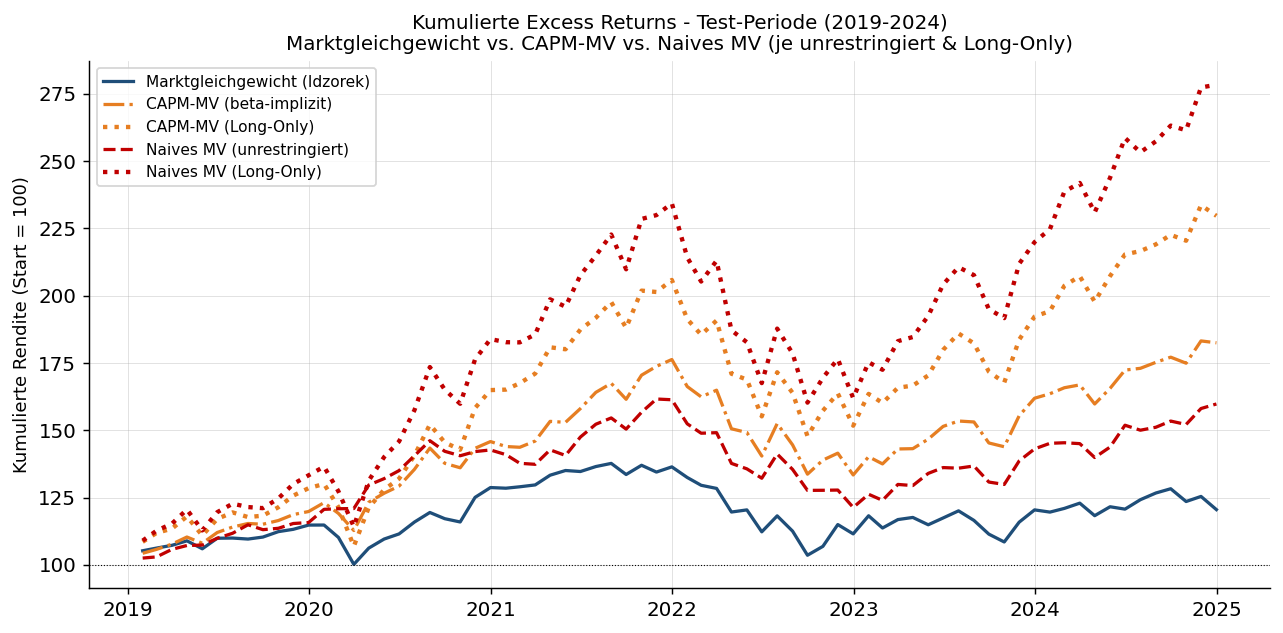

In [8]:
train_mask = (df.index >= "2008-01-01") & (df.index <= "2018-12-31")
test_mask  = (df.index >= "2019-01-01") & (df.index <= "2024-12-31")
df_train   = df.loc[train_mask]
df_test    = df.loc[test_mask]

exc_train   = df_train[TICKERS].subtract(df_train["RF"], axis=0)
mkt_train   = df_train["Mkt-RF"].values      # market excess return, monthly
mu_train    = exc_train.mean().values
Sigma_train = exc_train.cov().values

# 1) CAPM Baseline: Idzorek Marktgleichgewichtsgewichte
w_eq_arr  = np.array([ETF_META[t]["w_eq"] for t in TICKERS])
w_eq      = w_eq_arr / w_eq_arr.sum()

# 2) CAPM-MV: beta-implizierte Erwartungsrenditen -> Tangentialportfolio
# CAPM: E[R_i - r_f] = β_i * E[R_M - r_f], daher µ_CAPM_i = β_i * µ_market
betas = np.array([out.loc[t, "beta"] for t in TICKERS])
mu_market_ann = mkt_train.mean() * 12
mu_capm   = betas * mu_market_ann          # annualised CAPM-predicted excess returns
# monthly scale for MV:
mu_capm_m = mu_capm / 12
try:
    w_capm_raw = np.linalg.solve(Sigma_train, mu_capm_m)
except np.linalg.LinAlgError:
    w_capm_raw = np.linalg.lstsq(Sigma_train, mu_capm_m, rcond=None)[0]
w_capm = w_capm_raw / w_capm_raw.sum()

# 3) Naives MV: Stichprobenmittel -> Tangentialportfolio (unrestringiert)
try:
    w_mv_raw = np.linalg.solve(Sigma_train, mu_train)
except np.linalg.LinAlgError:
    w_mv_raw = np.linalg.lstsq(Sigma_train, mu_train, rcond=None)[0]
w_mv = w_mv_raw / w_mv_raw.sum()

# 4) Long-Only-Pendants (echte QP, w≥0 & Σw=1; core/optimize)
# Ein Leerverkaufsverbot wirkt als implizite Regularisierung (Jagannathan & Ma 2003).
from optimize import mv_weights, constraint_diagnostics
from black_litterman import implied_risk_aversion
delta_lo  = implied_risk_aversion(pd.Series(mkt_train), annualize=True, frequency="M")
Sigma_ann = Sigma_train * 12.0
w_capm_lo = np.asarray(mv_weights(mu_capm,       Sigma_ann, delta_lo, long_only=True))  # mu_capm bereits annualisiert
w_mv_lo   = np.asarray(mv_weights(mu_train * 12, Sigma_ann, delta_lo, long_only=True))

diag_capm = constraint_diagnostics(w_capm, w_capm_lo)
diag_mv   = constraint_diagnostics(w_mv,   w_mv_lo)
print(f"delta (markt-impliziert) = {delta_lo:.3f}")
print(f"CAPM-MV : Shorts={diag_capm['n_short']}, Brutto-Exposure={diag_capm['gross_exposure']:.2f}, "
      f"Umschichtung->LO={diag_capm['turnover_to_lo']:.2f}")
print(f"Nai. MV : Shorts={diag_mv['n_short']}, Brutto-Exposure={diag_mv['gross_exposure']:.2f}, "
      f"Umschichtung->LO={diag_mv['turnover_to_lo']:.2f}")

print("\nPortfoliogewichte auf Trainingsdaten:")
print(f"  {'Ticker':<8} {'w_eq':>8} {'w_CAPM':>8} {'w_CAPM_LO':>10} {'w_MV':>8} {'w_MV_LO':>9}")
for i, t in enumerate(TICKERS):
    print(f"  {t:<8} {w_eq[i]*100:+7.1f}% {w_capm[i]*100:+7.1f}% {w_capm_lo[i]*100:+9.1f}% "
          f"{w_mv[i]*100:+7.1f}% {w_mv_lo[i]*100:+8.1f}%")

exc_test = df_test[TICKERS].subtract(df_test["RF"], axis=0)
ret_eq      = (exc_test * w_eq).sum(axis=1).rename("Marktgleichgewicht (Idzorek)")
ret_capm    = (exc_test * w_capm).sum(axis=1).rename("CAPM-MV (beta-implizit)")
ret_capm_lo = (exc_test * w_capm_lo).sum(axis=1).rename("CAPM-MV (Long-Only)")
ret_mv      = (exc_test * w_mv).sum(axis=1).rename("Naives MV (unrestringiert)")
ret_mv_lo   = (exc_test * w_mv_lo).sum(axis=1).rename("Naives MV (Long-Only)")

portfolios = {"Marktgleichgewicht (Idzorek)": ret_eq,
              "CAPM-MV (beta-implizit)":      ret_capm,
              "CAPM-MV (Long-Only)":          ret_capm_lo,
              "Naives MV (unrestringiert)":   ret_mv,
              "Naives MV (Long-Only)":        ret_mv_lo}

perf     = performance_summary(portfolios, frequency=12)
perf_pct = perf.copy()
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown", "Total Return"]:
    if col in perf_pct.columns:
        perf_pct[col] *= 100
print()
print(perf_pct.round(2))

colors_bt = {"Marktgleichgewicht (Idzorek)": C[0],
             "CAPM-MV (beta-implizit)":      "#e67e22",
             "CAPM-MV (Long-Only)":          "#e67e22",
             "Naives MV (unrestringiert)":   C[1],
             "Naives MV (Long-Only)":        C[1]}
lss = {"Marktgleichgewicht (Idzorek)": "-",
       "CAPM-MV (beta-implizit)":      "-.",
       "CAPM-MV (Long-Only)":          ":",
       "Naives MV (unrestringiert)":   "--",
       "Naives MV (Long-Only)":        ":"}
lws = {"Naives MV (Long-Only)": 2.4, "CAPM-MV (Long-Only)": 2.4}

fig, ax = plt.subplots(figsize=(10, 5))
for name, ret in portfolios.items():
    cr = cum_ret(ret) * 100
    ax.plot(cr.index, cr.values, label=name, color=colors_bt[name],
            linestyle=lss[name], linewidth=lws.get(name, 1.8))
ax.axhline(100, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Kumulierte Excess Returns - Test-Periode (2019-2024)\n"
             "Marktgleichgewicht vs. CAPM-MV vs. Naives MV (je unrestringiert & Long-Only)", fontsize=11)
ax.set_ylabel("Kumulierte Rendite (Start = 100)", fontsize=10)
ax.legend(fontsize=8.5)
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
display(fig)
plt.close(fig)
